#Potato Leaf Disease Detection using Image Classification

#Project Description
This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.

#Objectives
-  Understand image classification using deep learning
- Perform data preprocessing and augmentation
- Train and evaluate a CNN-based model

#Load data from kagglehub

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


#Data Understanding

**Visualize sample images from each class**

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
#Check Class Folders
classes = os.listdir(path)
print("Classes:", classes)

Classes: ['PlantVillage', 'PotatoPlants']


In [4]:
data_dir = os.path.join(path, "PlantVillage", "PlantVillage")
print(os.listdir(data_dir))

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


In [5]:
classes = os.listdir(data_dir)
print("Classes:", classes)

Classes: ['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


In [6]:
sample_images = {}

for cls in classes:
    class_path = os.path.join(data_dir, cls)

    all_images = []

    # Walk through all subfolders
    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                all_images.append(os.path.join(root, file))

    print(f"{cls}: {len(all_images)} images found")  # DEBUG

    if len(all_images) == 0:
        print(f"⚠️ No images found in {cls}")
        continue

    sample_images[cls] = random.choice(all_images)

Potato___healthy: 152 images found
Potato___Late_blight: 1000 images found
Potato___Early_blight: 1000 images found


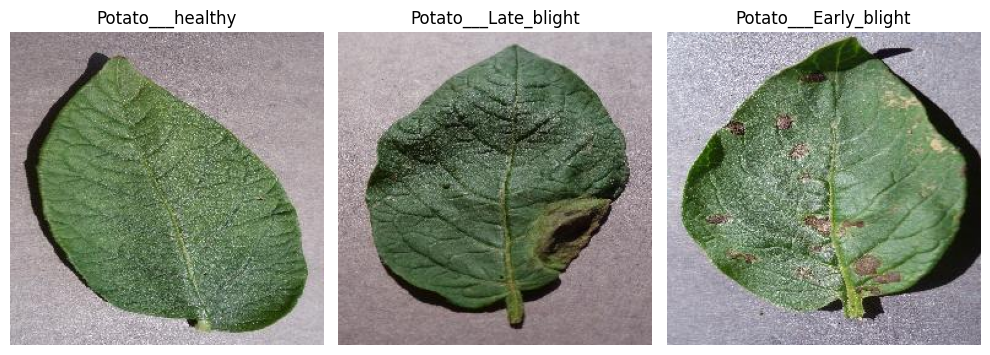

In [7]:
plt.figure(figsize=(10,5))

for i, (cls, img_path) in enumerate(sample_images.items()):
    img = Image.open(img_path)

    plt.subplot(1, len(sample_images), i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

#Data Preprocessing

##Resize images

In [8]:
import os
import cv2
import numpy as np

In [9]:
IMG_SIZE = 224   # You can also use 128

In [10]:
data = []
labels = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):

                img_path = os.path.join(root, file)

                try:
                    # Read image
                    img = cv2.imread(img_path)

                    # Resize image
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    # Append data
                    data.append(img)
                    labels.append(cls)

                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

In [11]:
X = np.array(data)
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2152, 224, 224, 3)
Shape of y: (2152,)


In [12]:
X = X / 255.0

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']


#Normalize pixel values

In [14]:
print("Min value:", X.min())
print("Max value:", X.max())

Min value: 0.0
Max value: 1.0


#Apply data augmentation (rotation, flipping, etc.)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,        # rotate image up to 20 degrees
    width_shift_range=0.1,    # shift horizontally
    height_shift_range=0.1,   # shift vertically
    shear_range=0.1,          # shear transformation
    zoom_range=0.2,           # zoom in/out
    horizontal_flip=True,     # flip horizontally
    fill_mode='nearest'       # fill missing pixels
)
datagen.fit(X)

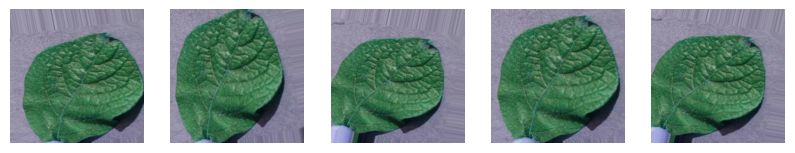

In [16]:
import matplotlib.pyplot as plt

sample_img = X[0]  # pick one image
sample_img = sample_img.reshape((1,) + sample_img.shape)

plt.figure(figsize=(10,5))

i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(1,5,i+1)
    plt.imshow(batch[0])
    plt.axis('off')

    i += 1
    if i == 5:
        break

plt.show()

#Model Building

**Build a CNN model**

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

# 🔹 1st Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 2nd Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 3rd Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 Flatten Layer
model.add(Flatten())

# 🔹 Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))   # prevent overfitting

# 🔹 Output Layer (3 classes)
model.add(Dense(3, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Define architecture, loss function, and optimizer**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Convolution + Pooling Layers
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (3 classes)
model.add(Dense(3, activation='softmax'))

In [19]:
loss = 'sparse_categorical_crossentropy'

In [20]:
optimizer = 'adam'

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Model Training

In [22]:
#Train the Model on Training Data
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2   # 20% of training used for validation
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - accuracy: 0.6512 - loss: 0.9554 - val_accuracy: 0.8754 - val_loss: 0.2836
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8626 - loss: 0.3500 - val_accuracy: 0.9362 - val_loss: 0.2083
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9084 - loss: 0.2476 - val_accuracy: 0.9275 - val_loss: 0.2106
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9324 - loss: 0.1838 - val_accuracy: 0.9333 - val_loss: 0.1947
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9390 - loss: 0.1534 - val_accuracy: 0.9623 - val_loss: 0.1266
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9644 - loss: 0.1060 - val_accuracy: 0.9710 - val_loss: 0.0820
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9608 - loss: 0.1146 - val_accuracy: 0.9768 - val_loss: 0.1024
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9695 - loss: 0.0825 - val_accuracy: 0.9362 -

In [23]:
#Test the Overall Model Performance
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9675 - loss: 0.0883
Test Loss: 0.08827260881662369
Test Accuracy: 0.9675173759460449


In [24]:
import numpy as np

predictions = model.predict(X_test)

# Convert probabilities → class labels
pred_classes = np.argmax(predictions, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


#Model Evaluation

In [25]:
#Accuracy
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9675 - loss: 0.0883
Test Accuracy: 0.9675173759460449


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


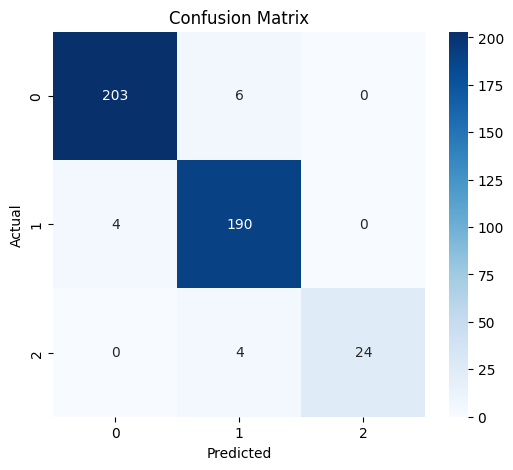

In [26]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       209
           1       0.95      0.98      0.96       194
           2       1.00      0.86      0.92        28

    accuracy                           0.97       431
   macro avg       0.98      0.94      0.95       431
weighted avg       0.97      0.97      0.97       431



In [29]:
model.save("potato_model.keras")